# Results on the MALL 5-min Feature Set

This notebook starts by loading and aligning the saved out-of-sample realized-volatility forecasts for all models evaluated under the MALL feature-set convention into one common evaluation panel.

## 1. Imports and Paths

Defining the forecast directories and importing the packages needed to construct the unified forecast panel.

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display

plt.style.use("default")

forecast_root_mhar = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR")
forecast_root_mall = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL")

## 2. Load and Align Forecasts

The saved forecast files are not fully uniform across model classes. Most models store the date index as `Unnamed: 0` and the forecast as `RV_forecast`, while the neural-network files store `Date` together with both `RV_forecast_best` and `RV_forecast_top10`. Under the MALL feature-set convention, `HAR-X` is loaded from the MALL benchmark-model folder, while the unchanged benchmark models (`HAR`, `LogHAR`, `LevHAR`, `SHAR`, and `HARQ`) continue to use the MHAR benchmark forecasts. The code below standardizes those formats and creates one merged data frame with the date, realized volatility, and one forecast column per model.

In [24]:
model_specs = [
    {"display_name": "HAR", "file_path": forecast_root_mhar / "Benchmark Models" / "forecasts_HAR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "HAR-X", "file_path": forecast_root_mall / "Benchmark Models" / "forecasts_HARX.csv", "forecast_column": "RV_forecast"},
    {"display_name": "LogHAR", "file_path": forecast_root_mhar / "Benchmark Models" / "forecasts_LogHAR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "LevHAR", "file_path": forecast_root_mhar / "Benchmark Models" / "forecasts_LevHAR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "SHAR", "file_path": forecast_root_mhar / "Benchmark Models" / "forecasts_SHAR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "HARQ", "file_path": forecast_root_mhar / "Benchmark Models" / "forecasts_HARQ.csv", "forecast_column": "RV_forecast"},
    {"display_name": "RR", "file_path": forecast_root_mall / "Regularized Linear Models" / "forecasts_RR.csv", "forecast_column": "RV_forecast"},
    {"display_name": "LA", "file_path": forecast_root_mall / "Regularized Linear Models" / "forecasts_LA.csv", "forecast_column": "RV_forecast"},
    {"display_name": "EN", "file_path": forecast_root_mall / "Regularized Linear Models" / "forecasts_EN.csv", "forecast_column": "RV_forecast"},
    {"display_name": "BG", "file_path": forecast_root_mall / "Tree-based Models" / "forecasts_BG.csv", "forecast_column": "RV_forecast"},
    {"display_name": "RF", "file_path": forecast_root_mall / "Tree-based Models" / "forecasts_RF.csv", "forecast_column": "RV_forecast"},
    {"display_name": "GB", "file_path": forecast_root_mall / "Tree-based Models" / "forecasts_GB.csv", "forecast_column": "RV_forecast"},
    {"display_name": "NN1_best", "file_path": forecast_root_mall / "Neural Networks" / "forecasts_NN1.csv", "forecast_column": "RV_forecast_best"},
    {"display_name": "NN1_top10", "file_path": forecast_root_mall / "Neural Networks" / "forecasts_NN1.csv", "forecast_column": "RV_forecast_top10"},
    {"display_name": "NN2_best", "file_path": forecast_root_mall / "Neural Networks" / "forecasts_NN2.csv", "forecast_column": "RV_forecast_best"},
    {"display_name": "NN2_top10", "file_path": forecast_root_mall / "Neural Networks" / "forecasts_NN2.csv", "forecast_column": "RV_forecast_top10"},
    {"display_name": "NN3_best", "file_path": forecast_root_mall / "Neural Networks" / "forecasts_NN3.csv", "forecast_column": "RV_forecast_best"},
    {"display_name": "NN3_top10", "file_path": forecast_root_mall / "Neural Networks" / "forecasts_NN3.csv", "forecast_column": "RV_forecast_top10"},
    {"display_name": "NN4_best", "file_path": forecast_root_mall / "Neural Networks" / "forecasts_NN4.csv", "forecast_column": "RV_forecast_best"},
    {"display_name": "NN4_top10", "file_path": forecast_root_mall / "Neural Networks" / "forecasts_NN4.csv", "forecast_column": "RV_forecast_top10"},
]

model_order = [spec["display_name"] for spec in model_specs]


def load_forecast_series(file_path: Path, forecast_column: str, display_name: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)

    if "Date" in df.columns:
        date_column = "Date"
    elif "Unnamed: 0" in df.columns:
        date_column = "Unnamed: 0"
    else:
        raise ValueError(f"No recognized date column found in {file_path}")

    required_columns = [date_column, "RV_actual", forecast_column]
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns {missing_columns} in {file_path}")

    df = df[required_columns].copy()
    df[date_column] = pd.to_datetime(df[date_column])
    df = df.rename(columns={date_column: "Date", forecast_column: display_name})
    return df.sort_values("Date").reset_index(drop=True)


actual_panel = None
forecast_panel = None

for spec in model_specs:
    model_df = load_forecast_series(
        file_path=spec["file_path"],
        forecast_column=spec["forecast_column"],
        display_name=spec["display_name"],
    )

    if actual_panel is None:
        actual_panel = model_df[["Date", "RV_actual"]].copy()
        forecast_panel = actual_panel.copy()
    else:
        actual_check = actual_panel.merge(
            model_df[["Date", "RV_actual"]],
            on="Date",
            how="inner",
            suffixes=("_baseline", "_candidate"),
        )
        if not np.allclose(
            actual_check["RV_actual_baseline"],
            actual_check["RV_actual_candidate"],
            equal_nan=True,
        ):
            raise ValueError(f"RV_actual does not align for {spec['display_name']}")

    forecast_panel = forecast_panel.merge(
        model_df[["Date", spec["display_name"]]],
        on="Date",
        how="inner",
    )

forecast_panel = forecast_panel[["Date", "RV_actual", *model_order]].sort_values("Date").reset_index(drop=True)
available_models = [model for model in model_order if model in forecast_panel.columns]
actual = forecast_panel["RV_actual"]

print(f"Common evaluation sample: {len(forecast_panel)} observations")
print(f"Evaluation period: {forecast_panel['Date'].min().date()} to {forecast_panel['Date'].max().date()}")
print(f"Number of forecast columns: {len(available_models)}")

display(forecast_panel.head())

Common evaluation sample: 1099 observations
Evaluation period: 2016-04-21 to 2020-08-06
Number of forecast columns: 20


,Date,RV_actual,HAR,HAR-X,LogHAR,LevHAR,SHAR,HARQ,RR,LA,...,RF,GB,NN1_best,NN1_top10,NN2_best,NN2_top10,NN3_best,NN3_top10,NN4_best,NN4_top10
0,2016-04-21,0.000053,0.000101,0.000039,0.000098,0.000053,0.000099,0.000104,0.000087,0.000082,...,0.000083,0.000088,0.000096,0.000109,0.000122,0.000099,0.000079,0.000098,0.000118,0.000109
1,2016-04-22,0.000081,0.000085,0.000057,0.000080,0.000065,0.000087,0.000070,0.000090,0.000077,...,0.000066,0.000078,0.000083,0.000089,0.000101,0.000093,0.000082,0.000098,0.000096,0.000101
2,2016-04-25,0.000066,0.000090,0.000073,0.000087,0.000081,0.000092,0.000085,0.000108,0.000092,...,0.000087,0.000086,0.000089,0.000094,0.000106,0.000104,0.000148,0.000111,0.000112,0.000105
3,2016-04-26,0.000059,0.000087,0.000072,0.000084,0.000058,0.000088,0.000077,0.000103,0.000091,...,0.000091,0.000086,0.000095,0.000102,0.000103,0.000097,0.000085,0.000103,0.000107,0.000108
4,2016-04-27,0.000097,0.000084,0.000076,0.000080,0.000068,0.000085,0.000072,0.000102,0.000091,...,0.000080,0.000079,0.000089,0.000100,0.000096,0.000097,0.000087,0.000105,0.000108,0.000106


## 3. Pairwise Relative MSE and Diebold--Mariano Test

For each ordered model pair $(i, j)$, the table reports the out-of-sample realized-variance forecast MSE of model $j$ relative to model $i$, that is, $MSE_j / MSE_i$. The significance markers come from a one-sided Diebold--Mariano test under squared-error loss, where the null is equal predictive accuracy and the alternative is that the column model has lower MSE than the row model.

For the EURO STOXX 50 time series, the loss differential is defined as

$$
d_t = e_{i,t}^2 - e_{j,t}^2,
$$

so stars on entry $(i, j)$ indicate evidence that the column model outperforms the row model.

In [27]:
display_label_map = {
    "HAR": "HAR",
    "HAR-X": "HAR-X",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "BG": "BG",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": "$\\mathbf{NN}_{1}^{1}$",
    "NN1_top10": "$\\mathbf{NN}_{1}^{10}$",
    "NN2_best": "$\\mathbf{NN}_{2}^{1}$",
    "NN2_top10": "$\\mathbf{NN}_{2}^{10}$",
    "NN3_best": "$\\mathbf{NN}_{3}^{1}$",
    "NN3_top10": "$\\mathbf{NN}_{3}^{10}$",
    "NN4_best": "$\\mathbf{NN}_{4}^{1}$",
    "NN4_top10": "$\\mathbf{NN}_{4}^{10}$",
}


def dm_test_one_sided(actual: pd.Series, forecast_i: pd.Series, forecast_j: pd.Series, h: int = 1):
    aligned = pd.concat([actual, forecast_i, forecast_j], axis=1).dropna()
    y = aligned.iloc[:, 0].to_numpy(dtype=float)
    f_i = aligned.iloc[:, 1].to_numpy(dtype=float)
    f_j = aligned.iloc[:, 2].to_numpy(dtype=float)

    d = (y - f_i) ** 2 - (y - f_j) ** 2
    T = len(d)
    if T < 5:
        return np.nan, np.nan

    mean_d = float(d.mean())
    centered = d - mean_d

    # For one-step-ahead forecasts, the long-run variance reduces to gamma_0.
    long_run_var = float(np.mean(centered ** 2))

    if long_run_var <= 1e-20:
        if abs(mean_d) <= 1e-20:
            return mean_d, 1.0
        return mean_d, 0.0 if mean_d > 0 else 1.0

    dm_stat = mean_d / np.sqrt(long_run_var / T)
    hln_adj = np.sqrt((T + 1 - 2 * h + (h * (h - 1)) / T) / T)
    dm_hln = dm_stat * hln_adj
    p_value = float(1 - stats.t.cdf(dm_hln, df=T - 1))
    return mean_d, p_value


def star_label(p_value: float) -> str:
    if pd.isna(p_value):
        return ""
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


mse_by_model = {
    model: float(np.mean((actual - forecast_panel[model]) ** 2))
    for model in available_models
}

relative_mse_matrix = pd.DataFrame(index=available_models, columns=available_models, dtype=float)
dm_pvalue_matrix = pd.DataFrame(index=available_models, columns=available_models, dtype=float)
pairwise_relative_mse_table = pd.DataFrame(index=available_models, columns=available_models, dtype=object)

for row_model in available_models:
    for col_model in available_models:
        if row_model == col_model:
            relative_mse_matrix.loc[row_model, col_model] = np.nan
            dm_pvalue_matrix.loc[row_model, col_model] = np.nan
            pairwise_relative_mse_table.loc[row_model, col_model] = "-"
            continue

        rel_mse = mse_by_model[col_model] / mse_by_model[row_model]
        _, p_value = dm_test_one_sided(actual, forecast_panel[row_model], forecast_panel[col_model], h=1)

        relative_mse_matrix.loc[row_model, col_model] = rel_mse
        dm_pvalue_matrix.loc[row_model, col_model] = p_value
        pairwise_relative_mse_table.loc[row_model, col_model] = f"{rel_mse:.3f}{star_label(p_value)}"

pairwise_relative_mse_display = pairwise_relative_mse_table.rename(index=display_label_map, columns=display_label_map)

styled_relative_mse = (
    pairwise_relative_mse_display.style
    .set_caption("Table: One-step-ahead relative MSE and Diebold-Mariano test for the MALL feature set")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "thead th", "props": [("font-size", "12px"), ("text-align", "center"), ("border-bottom", "1px solid black"), ("padding", "6px")]},
        {"selector": "tbody th", "props": [("font-size", "12px"), ("text-align", "left"), ("padding", "6px"), ("font-weight", "bold")]},
        {"selector": "tbody td", "props": [("font-size", "12px"), ("text-align", "center"), ("padding", "6px")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
    ])
)

display(styled_relative_mse)

,HAR,HAR-X,LogHAR,LevHAR,SHAR,HARQ,RR,LA,EN,BG,RF,GB,$\mathbf{NN}_{1}^{1}$,$\mathbf{NN}_{1}^{10}$,$\mathbf{NN}_{2}^{1}$,$\mathbf{NN}_{2}^{10}$,$\mathbf{NN}_{3}^{1}$,$\mathbf{NN}_{3}^{10}$,$\mathbf{NN}_{4}^{1}$,$\mathbf{NN}_{4}^{10}$
HAR,-,0.932*,0.936**,0.951,1.031,0.846**,0.919*,0.897**,0.897**,0.948,0.855*,0.992,0.909,0.946,0.942,0.956,0.993,1.016,0.987,1.014
HAR-X,1.073,-,1.005,1.020,1.106,0.908**,0.987,0.962*,0.962*,1.017,0.917,1.065,0.975,1.016,1.011,1.026,1.065,1.091,1.059,1.089
LogHAR,1.068,0.996,-,1.016,1.101,0.904**,0.982,0.958**,0.958**,1.013,0.913,1.060,0.971,1.011,1.007,1.021,1.061,1.086,1.054,1.084
LevHAR,1.052,0.980,0.984,-,1.084,0.890**,0.967,0.943*,0.943*,0.997,0.899*,1.043,0.956,0.995,0.991,1.005,1.044,1.069,1.038,1.067
SHAR,0.970,0.904*,0.908*,0.922,-,0.821**,0.892*,0.870**,0.870**,0.920,0.829*,0.962,0.882,0.918,0.914,0.927,0.963,0.986,0.957,0.984
HARQ,1.182,1.101,1.106,1.124,1.218,-,1.087,1.060,1.060,1.120,1.010,1.172,1.074,1.118,1.113,1.129,1.173,1.201,1.166,1.199
RR,1.088,1.013,1.018,1.034,1.121,0.920*,-,0.975*,0.975*,1.031,0.929,1.079,0.988,1.029,1.025,1.039,1.080,1.105,1.073,1.103
LA,1.115,1.039,1.044,1.061,1.150,0.944,1.026,-,1.000,1.057,0.953,1.107,1.014,1.056,1.051,1.066,1.107,1.133,1.100,1.131
EN,1.115,1.039,1.044,1.060,1.149,0.944,1.025,1.000**,-,1.057,0.953,1.106,1.013,1.055,1.051,1.066,1.107,1.133,1.100,1.131
BG,1.055,0.983,0.987,1.003,1.087,0.893,0.970,0.946,0.946,-,0.901**,1.046,0.958,0.998,0.994,1.008,1.047,1.072,1.041,1.070


**Notes:** Each entry reports the out-of-sample realized-variance forecast MSE of the selected column model relative to the selected row model. Values below `1.000` indicate that the column model has a lower MSE than the row model. The significance markers are based on a one-sided Diebold--Mariano test under squared-error loss, so they should be interpreted as time-series evidence for this single EURO STOXX 50 series rather than as a cross-sectional summary across many assets.

## 4. Cleveland Dot-Plot: Relative MSE Ranking vs HAR

The Cleveland dot-plot below ranks all models from best to worst using their out-of-sample realized-variance forecast MSE relative to the standard HAR benchmark. Under the MALL feature-set convention, that HAR benchmark is the unchanged benchmark forecast loaded from the MHAR benchmark-model folder. Values to the left of `1.0` indicate an improvement over HAR, while values to the right indicate weaker performance than HAR. The labels next to the dots report the relative MSE, and the significance markers reflect the one-sided Diebold--Mariano comparison against HAR from section 3.

Saved figure to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results/MALL_Dot_plot.pdf


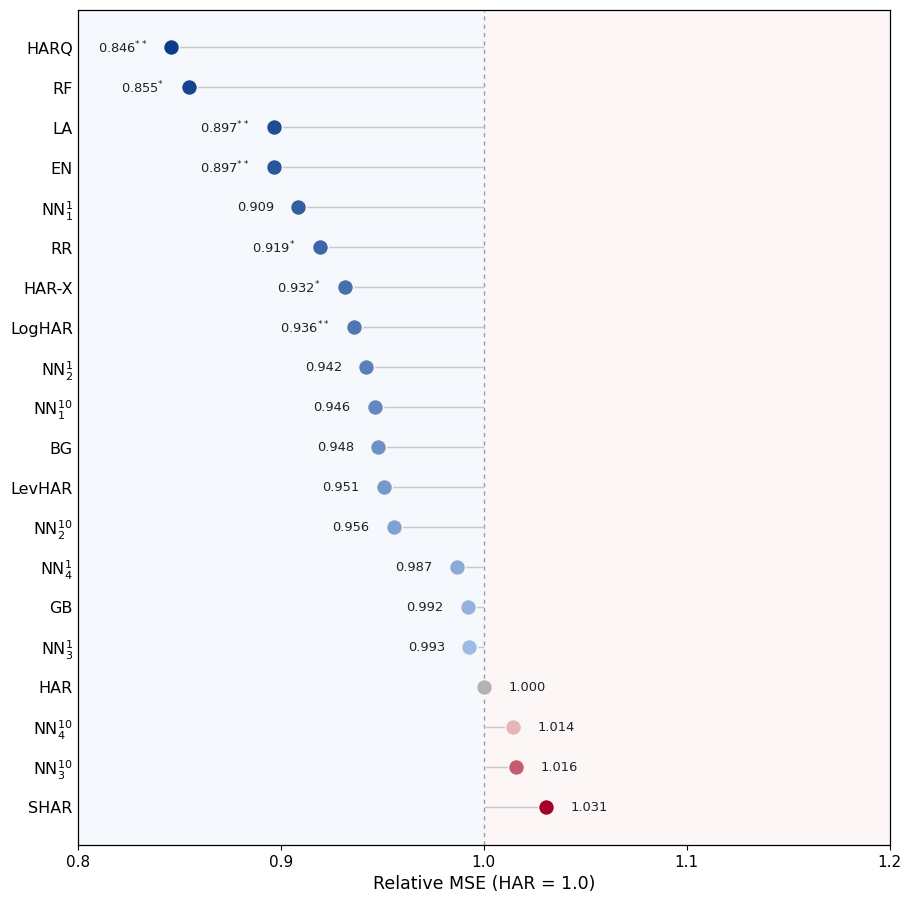

In [31]:
relative_to_har = pd.Series({model: mse / mse_by_model["HAR"] for model, mse in mse_by_model.items()})
relative_to_har = relative_to_har.loc[available_models].sort_values()

category_map = {
    "HAR": "Benchmark Models",
    "HAR-X": "Benchmark Models",
    "LogHAR": "Benchmark Models",
    "LevHAR": "Benchmark Models",
    "SHAR": "Benchmark Models",
    "HARQ": "Benchmark Models",
    "RR": "Regularized Models",
    "LA": "Regularized Models",
    "EN": "Regularized Models",
    "BG": "Tree-based Models",
    "RF": "Tree-based Models",
    "GB": "Tree-based Models",
    "NN1_best": "Neural Networks (Best)",
    "NN2_best": "Neural Networks (Best)",
    "NN3_best": "Neural Networks (Best)",
    "NN4_best": "Neural Networks (Best)",
    "NN1_top10": "Neural Networks (Ensemble)",
    "NN2_top10": "Neural Networks (Ensemble)",
    "NN3_top10": "Neural Networks (Ensemble)",
    "NN4_top10": "Neural Networks (Ensemble)",
}


def hex_to_rgb(hex_color: str) -> np.ndarray:
    hex_color = hex_color.lstrip("#")
    return np.array([int(hex_color[i:i + 2], 16) for i in (0, 2, 4)], dtype=float)


def rgb_to_hex(rgb: np.ndarray) -> str:
    rgb = np.clip(np.round(rgb), 0, 255).astype(int)
    return "#%02x%02x%02x" % tuple(rgb)


def interpolate_hex(start_hex: str, end_hex: str, n: int) -> list[str]:
    if n <= 0:
        return []
    if n == 1:
        return [start_hex]
    start_rgb = hex_to_rgb(start_hex)
    end_rgb = hex_to_rgb(end_hex)
    weights = np.linspace(0.0, 1.0, n)
    return [rgb_to_hex((1 - weight) * start_rgb + weight * end_rgb) for weight in weights]


plot_label_map = {
    "HAR": "HAR",
    "HAR-X": "HAR-X",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "BG": "BG",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": r"$\mathrm{NN}_{1}^{1}$",
    "NN1_top10": r"$\mathrm{NN}_{1}^{10}$",
    "NN2_best": r"$\mathrm{NN}_{2}^{1}$",
    "NN2_top10": r"$\mathrm{NN}_{2}^{10}$",
    "NN3_best": r"$\mathrm{NN}_{3}^{1}$",
    "NN3_top10": r"$\mathrm{NN}_{3}^{10}$",
    "NN4_best": r"$\mathrm{NN}_{4}^{1}$",
    "NN4_top10": r"$\mathrm{NN}_{4}^{10}$",
}

plot_models = relative_to_har.index.tolist()
plot_values = relative_to_har.values
benchmark_models = [model for model in ["HAR"] if model in plot_models]
left_models = [model for model in plot_models if model not in benchmark_models and relative_to_har[model] < 1.0]
right_models = [model for model in plot_models if model not in benchmark_models and relative_to_har[model] > 1.0]

point_color_map = {model: "#b3b3b3" for model in benchmark_models}
for model, color in zip(left_models, interpolate_hex("#0b3c8a", "#9dbbe5", len(left_models))):
    point_color_map[model] = color
for model, color in zip(right_models, interpolate_hex("#e6b5b5", "#a50026", len(right_models))):
    point_color_map[model] = color

x_min = 0.80
x_max = 1.20
y_step = 1.22
y_pos = np.arange(len(plot_models)) * y_step
y_labels = [plot_label_map.get(model, model) for model in plot_models]

fig, ax = plt.subplots(figsize=(11.6, 9.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.axvspan(x_min, 1.0, color="#f5f8fc", zorder=0)
ax.axvspan(1.0, x_max, color="#fcf6f6", zorder=0)
ax.axvline(1.0, color="#9d9d9d", linestyle=(0, (3, 3)), linewidth=1.0, zorder=1)

for y, model, value in zip(y_pos, plot_models, plot_values):
    ax.hlines(y, 1.0, value, color="#c9c9c9", linewidth=1.05, zorder=1)
    ax.scatter(
        value,
        y,
        s=132,
        color=point_color_map[model],
        edgecolor="#f8f8f8",
        linewidth=1.1,
        zorder=3,
    )

    stars = "" if model == "HAR" else star_label(dm_pvalue_matrix.loc["HAR", model])
    label = rf"{value:.3f}$^{{{stars}}}$" if stars else f"{value:.3f}"
    offset = 0.012

    if value < 1.0:
        ax.text(value - offset, y, label, ha="right", va="center", fontsize=9.4, color="#222222", zorder=4)
    elif value > 1.0:
        ax.text(value + offset, y, label, ha="left", va="center", fontsize=9.4, color="#222222", zorder=4)
    else:
        ax.text(value + offset, y, label, ha="left", va="center", fontsize=9.4, color="#222222", zorder=4)

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=11.5, fontweight="normal")
ax.invert_yaxis()
ax.set_xlim(x_min, x_max)
ax.set_xticks(np.arange(0.8, 1.21, 0.1))
ax.set_xlabel("Relative MSE (HAR = 1.0)", fontsize=12.5)
ax.tick_params(axis="x", labelsize=11.0)
ax.tick_params(axis="y", length=0)
ax.grid(False, axis="x")
ax.grid(False, axis="y")

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color("#000000")
    ax.spines[spine].set_linewidth(0.9)

plt.subplots_adjust(left=0.26, right=0.96, top=0.96, bottom=0.09)

export_path = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results/MALL_Dot_plot.pdf")
export_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(export_path, format="pdf", bbox_inches="tight")
print(f"Saved figure to: {export_path}")

plt.show()

**Notes:** The models are ordered from the lowest to the highest relative MSE against HAR. Dots to the left of `1.0` outperform the benchmark, while dots to the right underperform it. The asterisks next to each value correspond to the one-sided Diebold--Mariano test of the null of equal predictive accuracy against the alternative that the selected model improves on HAR.

## 5. Model Confidence Set

The Model Confidence Set (MCS) provides a statistical shortlist of models that cannot be ruled out as belonging to the set of best-performing models at a chosen confidence level. Here, the comparison is based on squared forecast error loss for the models evaluated under the MALL feature-set convention,

$$
\ell_{i,t} = \left(RV_t - \widehat{RV}_{i,t}\right)^2,
$$

and the MCS is constructed using the `Tmax` procedure of Hansen, Lunde, and Nason (2011). Starting from the full model universe, the procedure repeatedly tests the null of equal predictive ability across the remaining models. If the null is rejected, the model with the largest standardized excess loss is eliminated. The algorithm stops at the first non-rejection, and the surviving models form the final MCS.

For this first implementation, the MCS is computed using:

- squared-error loss,
- a `90%` confidence level (`alpha = 0.10`),
- a moving block bootstrap to account for dependence in the loss series, and
- a rule-based block length equal to `sqrt(T)`.

In [51]:
mcs_alpha = 0.10
mcs_bootstrap_reps = 1000
mcs_seed = 12345

loss_matrix = np.square(forecast_panel[available_models].subtract(actual, axis=0))
mcs_block_length = int(np.sqrt(len(loss_matrix)))


def compute_relative_average_losses(losses: np.ndarray) -> np.ndarray:
    model_count = losses.shape[1]
    row_sum = losses.sum(axis=1, keepdims=True)
    return (model_count * losses - row_sum) / (model_count - 1)


def moving_block_bootstrap_indices(n_obs: int, block_length: int, rng: np.random.Generator) -> np.ndarray:
    num_blocks = int(np.ceil(n_obs / block_length))
    block_starts = rng.integers(0, n_obs - block_length + 1, size=num_blocks)
    indices = np.concatenate([np.arange(start, start + block_length) for start in block_starts])
    return indices[:n_obs]


def run_mcs_tmax(
    losses: pd.DataFrame,
    alpha: float = 0.10,
    bootstrap_reps: int = 1000,
    block_length: int | None = None,
    seed: int = 12345,
):
    losses_array = losses.to_numpy(dtype=float)
    model_names = list(losses.columns)
    n_obs = losses_array.shape[0]
    block_length = block_length or int(np.sqrt(n_obs))
    rng = np.random.default_rng(seed)

    active_indices = list(range(len(model_names)))
    elimination_rows = []
    test_path_rows = []

    round_number = 1
    while len(active_indices) > 1:
        active_losses = losses_array[:, active_indices]
        relative_losses = compute_relative_average_losses(active_losses)
        observed_means = relative_losses.mean(axis=0)

        bootstrap_means = np.empty((bootstrap_reps, len(active_indices)))
        for b in range(bootstrap_reps):
            sample_indices = moving_block_bootstrap_indices(n_obs, block_length, rng)
            bootstrap_relative_losses = compute_relative_average_losses(active_losses[sample_indices, :])
            bootstrap_means[b, :] = bootstrap_relative_losses.mean(axis=0)

        variance_hat = bootstrap_means.var(axis=0, ddof=1)
        variance_hat = np.maximum(variance_hat, 1e-16)

        t_statistics = observed_means / np.sqrt(variance_hat)
        observed_tmax = float(np.max(t_statistics))
        bootstrap_tmax = np.max((bootstrap_means - observed_means) / np.sqrt(variance_hat), axis=1)
        epa_pvalue = float(np.mean(bootstrap_tmax >= observed_tmax))

        local_worst_index = int(np.argmax(t_statistics))
        global_worst_index = active_indices[local_worst_index]
        worst_model = model_names[global_worst_index]

        test_path_rows.append(
            {
                "Round": round_number,
                "Models_Remaining": len(active_indices),
                "Tmax_Statistic": observed_tmax,
                "EPA_pvalue": epa_pvalue,
                "Candidate_Elimination": worst_model,
            }
        )

        if epa_pvalue >= alpha:
            break

        elimination_rows.append(
            {
                "Elimination_Step": len(elimination_rows) + 1,
                "Model": worst_model,
                "EPA_pvalue": epa_pvalue,
                "Tmax_Statistic": observed_tmax,
            }
        )
        active_indices.pop(local_worst_index)
        round_number += 1

    included_models = [model_names[index] for index in active_indices]
    excluded_models = [row["Model"] for row in elimination_rows]

    model_pvalues = {model: 1.0 for model in included_models}
    running_pvalue = 0.0
    for row in elimination_rows:
        running_pvalue = max(running_pvalue, row["EPA_pvalue"])
        model_pvalues[row["Model"]] = running_pvalue

    return {
        "included_models": included_models,
        "excluded_models": excluded_models,
        "test_path": pd.DataFrame(test_path_rows),
        "elimination_table": pd.DataFrame(elimination_rows),
        "model_pvalues": model_pvalues,
    }


mcs_results = run_mcs_tmax(
    losses=loss_matrix,
    alpha=mcs_alpha,
    bootstrap_reps=mcs_bootstrap_reps,
    block_length=mcs_block_length,
    seed=mcs_seed,
)

mcs_included_models = mcs_results["included_models"]
mcs_excluded_models = mcs_results["excluded_models"]
mcs_test_path = mcs_results["test_path"]
mcs_elimination_table = mcs_results["elimination_table"]
mcs_model_pvalues = mcs_results["model_pvalues"]

elimination_step_map = {row["Model"]: row["Elimination_Step"] for row in mcs_elimination_table.to_dict("records")}

mcs_summary = pd.DataFrame(
    {
        "Model": available_models,
        "Mean_Squared_Loss": [loss_matrix[model].mean() for model in available_models],
        "Relative_MSE_vs_HAR": [mse_by_model[model] / mse_by_model["HAR"] for model in available_models],
        "MCS_Status": ["Included" if model in mcs_included_models else "Excluded" for model in available_models],
        "Elimination_Step": [elimination_step_map.get(model, pd.NA) for model in available_models],
        "MCS_pvalue": [mcs_model_pvalues[model] for model in available_models],
    }
)

mcs_summary = (
    mcs_summary
    .assign(MCS_Status_Sort=lambda df: (df["MCS_Status"] != "Included").astype(int))
    .sort_values(by=["MCS_Status_Sort", "Relative_MSE_vs_HAR", "Mean_Squared_Loss"], ascending=[True, True, True])
    .drop(columns="MCS_Status_Sort")
    .reset_index(drop=True)
)

print("MCS setup:")
print(f"  - confidence level: {1 - mcs_alpha:.0%}")
print(f"  - bootstrap replications: {mcs_bootstrap_reps}")
print(f"  - moving block length: {mcs_block_length}")
print()
print("Final MCS (models not rejected as inferior):")
for model in mcs_included_models:
    print(f"  - {model}")
if len(mcs_included_models) == len(available_models):
    print("\nThe equal predictive ability null is not rejected for the full model set, so all models remain in the MCS at this confidence level.")

display(mcs_summary.round({"Mean_Squared_Loss": 10, "Relative_MSE_vs_HAR": 4, "MCS_pvalue": 4}))
display(mcs_test_path.round({"Tmax_Statistic": 4, "EPA_pvalue": 4}))

MCS setup:
  - confidence level: 90%
  - bootstrap replications: 1000
  - moving block length: 33

Final MCS (models not rejected as inferior):
  - HAR
  - HAR-X
  - LogHAR
  - LevHAR
  - SHAR
  - HARQ
  - RR
  - LA
  - EN
  - BG
  - RF
  - GB
  - NN1_best
  - NN1_top10
  - NN2_best
  - NN2_top10
  - NN3_best
  - NN3_top10
  - NN4_best
  - NN4_top10

The equal predictive ability null is not rejected for the full model set, so all models remain in the MCS at this confidence level.


,Model,Mean_Squared_Loss,Relative_MSE_vs_HAR,MCS_Status,Elimination_Step,MCS_pvalue
0,HARQ,4.790000e-08,0.8462,Included,<NA>,1.0
1,RF,4.840000e-08,0.8546,Included,<NA>,1.0
2,LA,5.080000e-08,0.8966,Included,<NA>,1.0
3,EN,5.080000e-08,0.8968,Included,<NA>,1.0
4,NN1_best,5.150000e-08,0.9087,Included,<NA>,1.0
5,RR,5.210000e-08,0.9194,Included,<NA>,1.0
6,HAR-X,5.280000e-08,0.9318,Included,<NA>,1.0
7,LogHAR,5.300000e-08,0.9360,Included,<NA>,1.0
8,NN2_best,5.340000e-08,0.9422,Included,<NA>,1.0
9,NN1_top10,5.360000e-08,0.9463,Included,<NA>,1.0


,Round,Models_Remaining,Tmax_Statistic,EPA_pvalue,Candidate_Elimination
0,1,20,0.4918,0.57,SHAR


**Notes:** The MCS summary should be interpreted as a set-valued ranking device rather than a winner-takes-all test. Models labeled `Included` are those that survive the sequential `Tmax` elimination procedure at the `90%` confidence level. The `MCS_pvalue` column reports the model-wise inclusion p-value implied by the elimination path, while `Elimination_Step` shows when a model is removed from the candidate set. If the procedure stops immediately without eliminating any model, then the informative quantity is the first-round `EPA_pvalue` reported in the test-path table below. For a final thesis version, the bootstrap replications can be increased further if you want a smoother numerical approximation.